# Markov Chains and Mixing Times

For a stochastic matrix $P$, the distribution evolves as
$$
\pi_{t+1} = \pi_t P.
$$
Mixing speed is linked to the spectral gap $1-|\lambda_2|$. We compare total variation decay from different starts.


## Environment and Imports

We prepare numerical and visualization tools. The notebook writes a square representative image to
`python/markov-chains-mixing/snippet.png` so the search homepage can display it directly.


In [1]:
from pathlib import Path
import math
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.grid"] = True
plt.rcParams["font.size"] = 11

OUTPUT_DIR = Path("python/markov-chains-mixing") if Path("python/markov-chains-mixing").exists() else Path(".")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
rng = np.random.default_rng(0)


## Core Construction

We now implement the main ideas for **Markov Chains and Mixing Times**, with equations and plots designed to expose both the model and the numerical behavior.


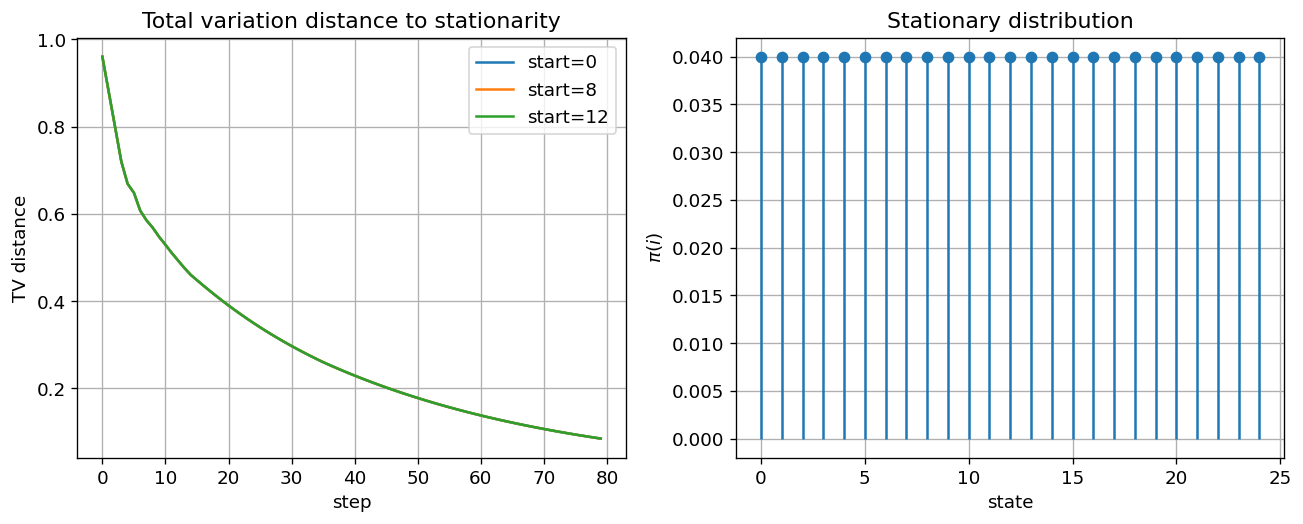

In [2]:
n = 25
P = np.zeros((n, n))
for i in range(n):
    P[i, i] += 0.2
    P[i, (i-1) % n] += 0.4
    P[i, (i+1) % n] += 0.4

eigvals, eigvecs = np.linalg.eig(P.T)
idx = np.argmin(np.abs(eigvals - 1))
pi = np.real(eigvecs[:, idx])
pi = np.abs(pi)
pi /= pi.sum()

starts = [0, n//3, n//2]
T = 80
tvd = []
for s in starts:
    mu = np.zeros(n); mu[s] = 1.0
    curve = []
    for _ in range(T):
        curve.append(0.5*np.sum(np.abs(mu - pi)))
        mu = mu @ P
    tvd.append(curve)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for s, curve in zip(starts, tvd):
    axes[0].plot(curve, label=f"start={s}")
axes[0].set_title("Total variation distance to stationarity")
axes[0].set_xlabel("step")
axes[0].set_ylabel("TV distance")
axes[0].legend()

axes[1].stem(np.arange(n), pi, basefmt=" ")
axes[1].set_title("Stationary distribution")
axes[1].set_xlabel("state")
axes[1].set_ylabel(r"$\pi(i)$")

plt.tight_layout()
fig.savefig(OUTPUT_DIR / "snippet.png", bbox_inches="tight")
plt.show()


### References

- D. A. Levin, Y. Peres, E. L. Wilmer, *Markov Chains and Mixing Times*.
- N. L. Johnson, S. Kotz, *Discrete Distributions* (foundational Markov material).
